# La Gomera Weekly Audit + EDA

**Project:** Climate–Mortality  
#### EDA scope for this notebook
#### Island: set via `gomera`
#### Dataset version used here: 2016–2025

**Saved outputs:** QA tables and key descriptive tables (CSV) under `reports/islands/tables/gomera`.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ISLAND_NAME = "gomera"
ISLAND_CODE = "gom"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

CWD : C:\dev\projects\climate_mortality\islands\gomera
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\gomera
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\gomera
FP: C:\dev\projects\climate_mortality\data\processed\gomera\master\master_gom_2016_2025.parquet


## 1. Load data
Load the island master dataset and subset.

In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)


EDA core weekly gomera
Loaded: C:\dev\projects\climate_mortality\data\processed\gomera\master\master_gom_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_gom ---
shape: (523, 45)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
n_days                                float64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                     

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,gomera,gom,4.0,0,2.0,19.050000,23.150000,23.2,...,67.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,gomera,gom,5.0,0,7.0,19.185714,22.085714,23.5,...,71.285714,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,gomera,gom,3.0,0,7.0,21.271429,24.585714,26.3,...,59.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,gomera,gom,7.0,0,7.0,19.814286,23.242857,25.2,...,71.428571,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,gomera,gom,5.0,0,7.0,20.685714,24.114286,26.2,...,80.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
year,523.0,2020.491396,2.883003,2015.000000,2018.000000,2020.000000,2023.000000,2025.000000
deaths_week,505.0,4.093069,1.973347,0.000000,3.000000,4.000000,5.000000,10.000000
deaths_missing_week,523.0,0.034417,0.182472,0.000000,0.000000,0.000000,0.000000,1.000000
n_days,471.0,6.955414,0.357484,2.000000,7.000000,7.000000,7.000000,7.000000
temp_c_mean,471.0,22.242165,2.596918,17.071429,20.035714,21.942857,24.492857,29.600000
tmax_c_mean,471.0,24.974366,2.733014,19.285714,22.771429,24.671429,26.953571,34.100000
tmax_c_max,471.0,27.001274,3.680928,19.800000,24.500000,26.400000,28.500000,41.900000
tmin_c_mean,471.0,19.511005,2.570053,14.485714,17.278571,19.400000,21.942857,25.514286
tmin_c_min,471.0,18.262633,2.810627,11.900000,15.900000,18.200000,20.900000,24.800000
humidity_mean,471.0,69.651198,7.481251,33.000000,65.571429,70.285714,74.714286,87.285714


In [3]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
elif "tmax_anom_mean" in df.columns:
    print("tmax_anom_mean already present.")
else:
    print("Missing base column tmax_c_mean.")

if {"deaths_week", "tmax_anom_mean"}.issubset(df.columns):
    corr_tmax_anom = df[["deaths_week", "tmax_anom_mean"]].dropna().corr().iloc[0, 1]
    print("Corr Tmax_anom:", corr_tmax_anom)

Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Corr Tmax_anom: -0.04209396860763962


In [4]:
if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")

Created excess_deaths from deaths_week using month-of-year mean.


In [5]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

df = df.sort_values("week_start").reset_index(drop=True)
glance(df, label=f"{ISLAND_CODE}_master_weekly", n=5)

calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score", "calima_proxy_level"]
    extra_keep = [c for c in [
        "cap_dust_yellow_plus_week",
        "cap_dust_level_max_week",
        "calima_dai_flag",
    ] if c in calima.columns]

    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)


--- gom_master_weekly ---
shape: (523, 48)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
n_days                                float64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                              float64
imputed_from_c329b                    float64
donor_station                          object
low_vis_confirmed_days_week           float64
low_vis_confirmed_any_week

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week,month,tmax_anom_mean,excess_deaths
0,2015-12-28,2015,gomera,gom,4.0,0,2.0,19.050000,23.150000,23.2,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,12,0.058512,-0.454545
1,2016-01-04,2016,gomera,gom,5.0,0,7.0,19.185714,22.085714,23.5,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,-0.116725,0.613636
2,2016-01-11,2016,gomera,gom,3.0,0,7.0,21.271429,24.585714,26.3,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,2.383275,-1.386364
3,2016-01-18,2016,gomera,gom,7.0,0,7.0,19.814286,23.242857,25.2,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,1.040418,2.613636
4,2016-01-25,2016,gomera,gom,5.0,0,7.0,20.685714,24.114286,26.2,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1,1.911847,0.613636


Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\gomera\calima\calima_proxy_weekly_gom_2016_2025.parquet
Dropping overlapping columns before merge: ['cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
Final shape: (523, 50)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.

In [6]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=3603
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
donor_station,503,0.9618
PM2.5,433,0.8279
calima_level_week,198,0.3786
calima_dai_flag,198,0.3786
cap_heat_level_max_week,129,0.2467
cap_coverage_week,129,0.2467
cap_dust_yellow_plus_week,129,0.2467
cap_dust_level_max_week,129,0.2467
cap_heat_yellow_plus_week,129,0.2467
confirmed_airports_max_week,63,0.1205


In [7]:
save_table(qa.reset_index(), TAB_DIR, f"{ISLAND_CODE}_qa_checks.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"{ISLAND_CODE}_missing_top50.csv")

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\gom_qa_checks.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\gom_missing_top50.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/gom_missing_top50.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).

## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.

In [8]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week",
]
desc = num_summary(df, cols=core_cols)
display(desc)

,count,mean,std,min,25%,50%,75%,max
deaths_week,505.0,4.093069,1.973347,0.000000,3.000000,4.000000,5.000000,10.000000
temp_c_mean,471.0,22.242165,2.596918,17.071429,20.035714,21.942857,24.492857,29.600000
tmax_c_mean,471.0,24.974366,2.733014,19.285714,22.771429,24.671429,26.953571,34.100000
tmin_c_mean,471.0,19.511005,2.570053,14.485714,17.278571,19.400000,21.942857,25.514286
humidity_mean,471.0,69.651198,7.481251,33.000000,65.571429,70.285714,74.714286,87.285714
pressure_hpa_mean,471.0,1015.415745,5.321793,989.250000,1014.042857,1015.750000,1017.696429,1025.464286
wind_ms_mean,470.0,3.411778,0.986528,0.000000,2.675000,3.307143,4.114286,6.157143
PM10,523.0,48.220533,50.393690,6.998157,23.214286,33.000000,51.285714,578.571429
PM2.5,90.0,16.993843,46.641105,2.000000,7.518601,9.469673,13.917484,448.000000
SO2,467.0,3.596722,3.071507,1.000000,1.857143,3.000000,4.142857,30.000000


In [9]:
save_table(desc, TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=True)

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\desc_core_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/desc_core_gom.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_weekly_deaths_timeseries.png


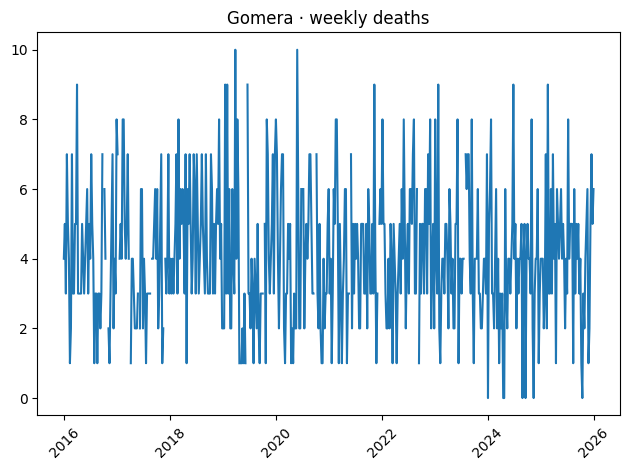

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_weekly_tmax_timeseries.png


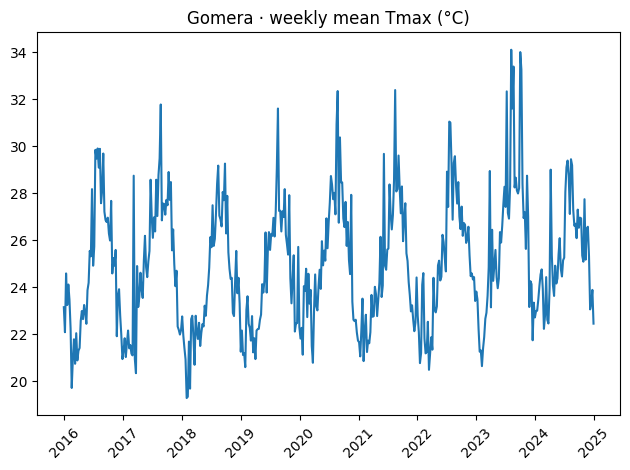

In [10]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME.capitalize()} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

if "tmax_c_mean" in df.columns:
    plt.figure()
    plt.plot(df["week_start"], df["tmax_c_mean"])
    plt.title(f"{ISLAND_NAME.capitalize()} · weekly mean Tmax (°C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
    plt.show()

## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_deaths_vs_absolute_tmax_scatter.png


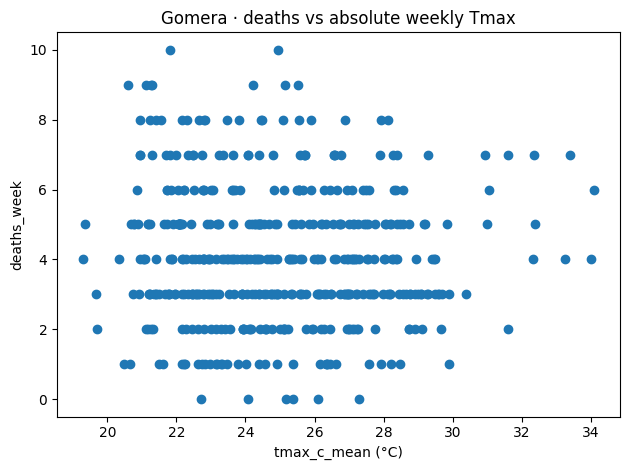

corr(deaths, tmax_c_mean): -0.0437


In [11]:
if {"tmax_c_mean", "deaths_week"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["tmax_c_mean"], df["deaths_week"])
    plt.xlabel("tmax_c_mean (°C)")
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs absolute weekly Tmax")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
    plt.show()

    corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
    print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))

##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_deaths_vs_temperature_anomaly_scatter.png


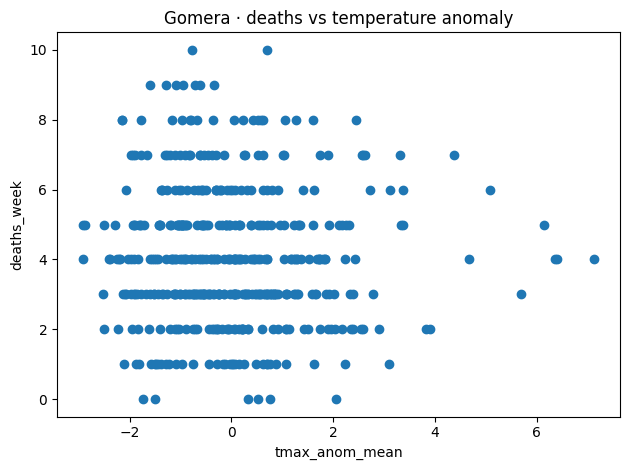

corr(deaths, tmax_anom_mean): -0.0421


In [12]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()

    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))

### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.

In [13]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Empirical thresholds from weekly tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

Empirical thresholds from weekly tmax_c_mean -> p90=28.47, p95=29.41
heat_p95
0    499
1     24
Name: count, dtype: int64


In [14]:
tmp = df.copy()
tab_p95 = tmp.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

,count,mean,median
heat_p95,,,
0,482,4.085062,4.0
1,23,4.260870,4.0


Δ deaths (heat_p95 vs baseline): 0.18


In [15]:
save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\heat_p95_deaths_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/heat_p95_deaths_gom.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.

float64
calima_dai_flag
0.000000    277
NaN         198
0.333333      5
0.370370      4
0.444444      4
1.500150      2
0.555556      2
0.350877      2
4.390458      2
0.517277      2
0.681849      2
0.919540      2
3.247808      2
7.794232      2
0.939920      1
0.416667      1
0.761905      1
0.796020      1
0.740741      1
0.512821      1
Name: count, dtype: int64


,missing,missing_pct
calima_proxy_score,0,0.0
calima_proxy_level,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_audit_missing_gom.csv


,calima_proxy_level,weeks
0,no_calima,363
1,possible,103
2,intense,30
3,probable,27


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_level_counts_gom.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_calima_proxy_level_distribution.png


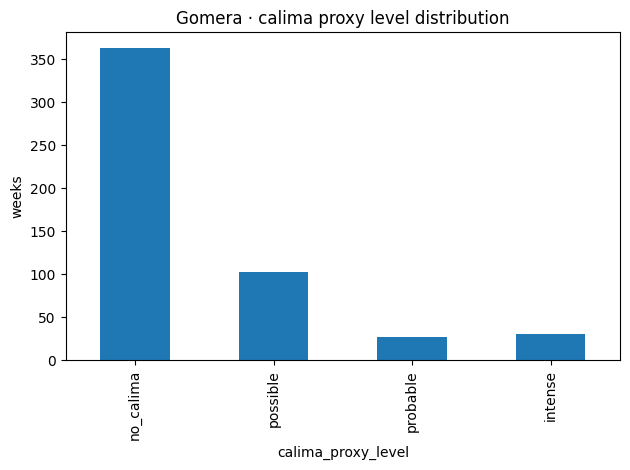

cap_dust_yellow_plus_week,0.0,1.0,NaN
calima_proxy_level,,,
intense,15,10,5
no_calima,257,2,104
possible,85,3,15
probable,19,3,5


In [16]:
proxy_cols = ["calima_proxy_score", "calima_proxy_level"]
have_proxy = all(c in df.columns for c in proxy_cols)

if "calima_dai_flag" in df.columns:
    print(df["calima_dai_flag"].dtype)
    print(df["calima_dai_flag"].value_counts(dropna=False).head(20))
else:
    print("calima_dai_flag not present in current dataset.")

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(
        proxy_na.reset_index().rename(columns={"index": "column"}),
        TAB_DIR,
        f"calima_proxy_audit_missing_{ISLAND_CODE}.csv",
        index=False
    )

    proxy_counts = (
        df["calima_proxy_level"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index]).dropna()

        plt.figure()
        plot_counts.plot(kind="bar")
        plt.ylabel("weeks")
        plt.title(f"{ISLAND_NAME.capitalize()} · calima proxy level distribution")
        plt.tight_layout()
        autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_calima_proxy_level_distribution.png")
        plt.show()

    if "cap_dust_yellow_plus_week" in df.columns:
        cap_xtab = pd.crosstab(df["calima_proxy_level"], df["cap_dust_yellow_plus_week"], dropna=False)
        display(cap_xtab)

In [17]:
score_dist = (
    df["calima_proxy_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("calima_proxy_score")
    .reset_index(name="weeks")
)

score_dist["pct"] = score_dist["weeks"] / len(df) * 100
score_dist["pct"] = score_dist["pct"].round(6)

display(score_dist)

save_table(
    score_dist,
    TAB_DIR,
    f"calima_proxy_score_distribution_{ISLAND_CODE}.csv",
    index=False
)

,calima_proxy_score,weeks,pct
0,0.0,291,55.640535
1,0.5,72,13.766730
2,1.0,73,13.957935
3,1.5,30,5.736138
4,2.0,22,4.206501
5,2.5,5,0.956023
6,3.0,11,2.103250
7,3.5,7,1.338432
8,4.0,8,1.529637
9,4.5,4,0.764818


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_score_distribution_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/calima_proxy_score_distribution_gom.csv')

In [18]:
score_level = df.groupby(["calima_proxy_score", "calima_proxy_level"]).size().reset_index(name="weeks")
display(score_level)
save_table(score_level, TAB_DIR, f"calima_proxy_score_to_level_{ISLAND_CODE}.csv", index=False)

,calima_proxy_score,calima_proxy_level,weeks
0,0.0,no_calima,291
1,0.5,no_calima,72
2,1.0,possible,73
3,1.5,possible,30
4,2.0,probable,22
5,2.5,probable,5
6,3.0,intense,11
7,3.5,intense,7
8,4.0,intense,8
9,4.5,intense,4


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_score_to_level_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/calima_proxy_score_to_level_gom.csv')

### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).

In [19]:
if "calima_proxy_level" in df.columns:
    cal = (
        df.groupby("calima_proxy_level")["deaths_week"]
        .agg(["count", "mean", "median", "min", "max", "std"])
        .sort_index()
    )
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)

if "intense" in cal.index and "no_calima" in cal.index:
    mean_intense = cal.loc["intense", "mean"]
    mean_baseline = cal.loc["no_calima", "mean"]
    delta_deaths = mean_intense - mean_baseline

    print(f"Mean deaths | intense   : {mean_intense:.2f}")
    print(f"Mean deaths | no_calima : {mean_baseline:.2f}")
    print(f"Δ deaths (calima intense vs baseline) = {delta_deaths:.2f}")

,count,mean,median,min,max,std
calima_proxy_level,,,,,,
intense,30,4.233333,3.5,1.0,9.0,2.176415
no_calima,350,4.042857,4.0,0.0,10.0,1.936201
possible,99,4.252525,4.0,0.0,9.0,2.081716
probable,26,4.000000,4.0,0.0,7.0,1.876166


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_level_v_deaths_gom.csv
Mean deaths | intense   : 4.23
Mean deaths | no_calima : 4.04
Δ deaths (calima intense vs baseline) = 0.19


In [20]:
tmp = df.copy()
tmp["month"] = pd.to_datetime(tmp["week_start"]).dt.month

month_proxy = (
    tmp.groupby(["month", "calima_proxy_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(month_proxy)

save_table(
    month_proxy,
    TAB_DIR,
    f"calima_proxy_level_by_month_{ISLAND_CODE}.csv",
    index=False
)

calima_proxy_level,month,intense,no_calima,possible,probable
0,1,6,26,11,2
1,2,7,24,5,5
2,3,2,33,6,2
3,4,3,33,6,1
4,5,0,37,8,0
5,6,1,31,8,2
6,7,1,31,10,3
7,8,1,31,9,3
8,9,1,32,9,1
9,10,1,36,5,3


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_level_by_month_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/calima_proxy_level_by_month_gom.csv')

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\deaths_by_calima_proxy_level_boxplot_gom.png


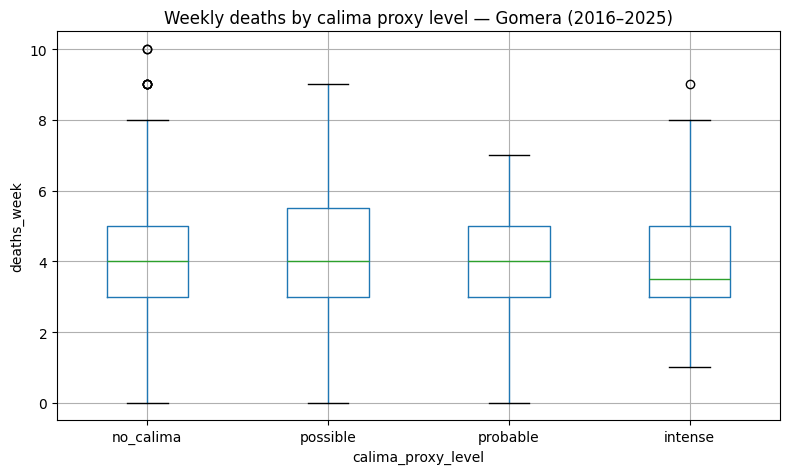

In [21]:
level_order = ["no_calima", "possible", "probable", "intense"]

plot_df = df.dropna(subset=["calima_proxy_level", "deaths_week"]).copy()
plot_df["calima_proxy_level"] = pd.Categorical(
    plot_df["calima_proxy_level"],
    categories=level_order,
    ordered=True
)
plot_df = plot_df.sort_values("calima_proxy_level")

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.boxplot(column="deaths_week", by="calima_proxy_level", ax=ax)

ax.set_title(f"Weekly deaths by calima proxy level — {ISLAND_NAME.capitalize()} (2016–2025)")
ax.set_xlabel("calima_proxy_level")
ax.set_ylabel("deaths_week")
plt.suptitle("")
plt.tight_layout()

autosave_fig(FIG_DIR / f"deaths_by_calima_proxy_level_boxplot_{ISLAND_CODE}.png")
plt.show()

## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.

In [22]:
tmp = df.copy()

if "calima_proxy_level" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(
    inter.reset_index(),
    TAB_DIR,
    f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv",
    index=False
)

count      mean  median
heat_p95 calima_intense                         
0        0                 453  4.081678     4.0
         1                  29  4.137931     3.0
1        0                  22  4.136364     4.0
         1                   1  7.000000     7.0

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\interaction_heat_p95_x_calima_intense_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/interaction_heat_p95_x_calima_intense_gom.csv')

### Key numbers to report

- Δ deaths (heat p95 vs baseline) = **0.18**
- Δ deaths (calima intense vs baseline) = **0.19 deaths/week**
- Proxy coverage / missingness = **0.0%**
- corr(deaths, tmax_c_mean) = **-0.0437**
- corr(deaths, Tmax anomaly) = **-0.0421**